Train shape: (10450, 12)
Test shape: (2613, 9)

Missing values:
 datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Data types:
 datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object


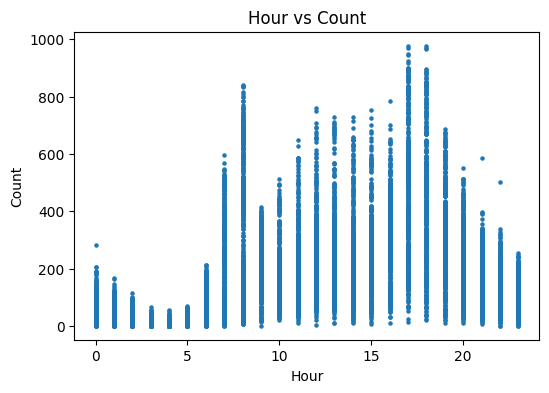

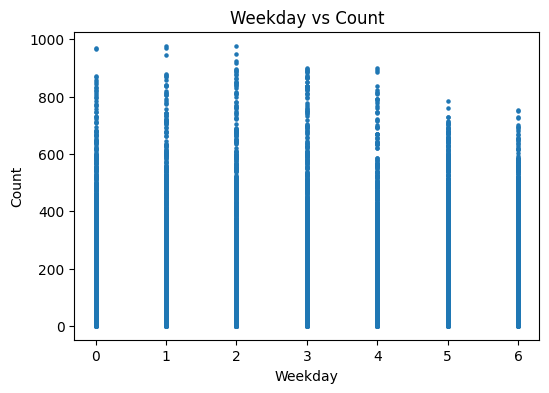

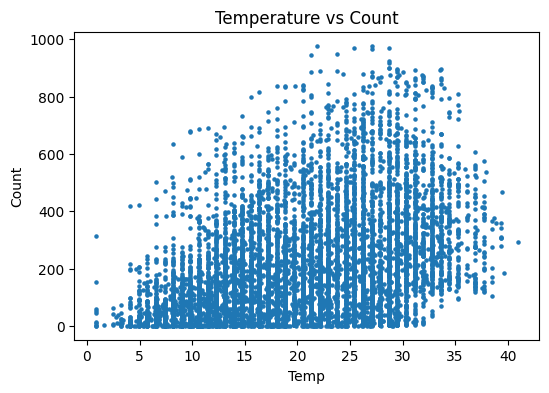

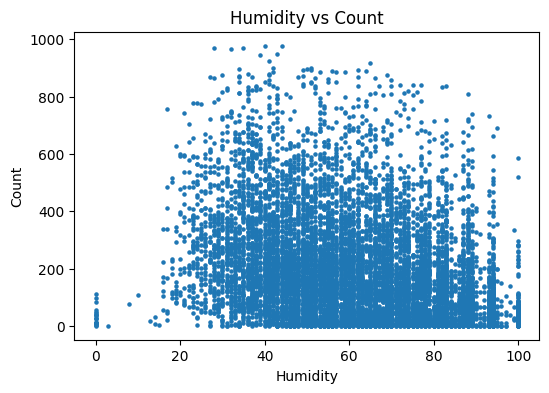


RMSLE – Linear Regression: 0.29285475648052345

RMSLE – Ridge: 0.3345794130211283
RMSLE – Lasso: 0.331555071786207

MODEL COMPARISON
--------------------------
Linear Regression : 0.29285475648052345
Polynomial + Ridge: 0.3345794130211283
Polynomial + Lasso: 0.331555071786207

Best Model: Lasso


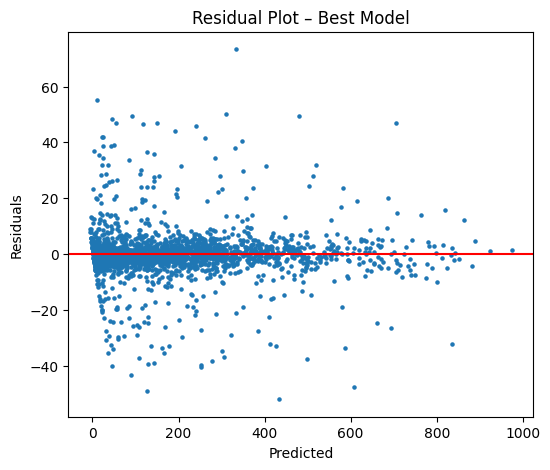

In [9]:
# ============================================
# ASSIGNMENT – BIKE SHARING DEMAND PREDICTION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures

# --------------------------------------------------
# Load datasets
# --------------------------------------------------
train = pd.read_csv("C:\\Users\\Santhoshn\\Downloads\\bike_train.csv")
test = pd.read_csv("C:\\Users\\Santhoshn\\Downloads\\bike_test.csv")

# --------------------------------------------------
# Q1 — Dataset overview
# --------------------------------------------------
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nMissing values:\n", train.isna().sum())
print("\nData types:\n", train.dtypes)

# --------------------------------------------------
# Q2 — Convert datetime + EDA visualizations (matplotlib only)
# --------------------------------------------------
train['datetime'] = pd.to_datetime(train['datetime'], errors='coerce')
test['datetime']  = pd.to_datetime(test['datetime'], errors='coerce')

# Feature extraction
train['hour'] = train['datetime'].dt.hour
train['weekday'] = train['datetime'].dt.weekday
train['month'] = train['datetime'].dt.month
train['year'] = train['datetime'].dt.year.map({2011:0, 2012:1})

test['hour'] = test['datetime'].dt.hour
test['weekday'] = test['datetime'].dt.weekday
test['month'] = test['datetime'].dt.month
test['year'] = test['datetime'].dt.year.map({2011:0, 2012:1})

# --- Visualization (matplotlib only) ---
plt.figure(figsize=(6,4))
plt.scatter(train['hour'], train['count'], s=5)
plt.title("Hour vs Count")
plt.xlabel("Hour"); plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(train['weekday'], train['count'], s=5)
plt.title("Weekday vs Count")
plt.xlabel("Weekday"); plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(train['temp'], train['count'], s=5)
plt.title("Temperature vs Count")
plt.xlabel("Temp"); plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(train['humidity'], train['count'], s=5)
plt.title("Humidity vs Count")
plt.xlabel("Humidity"); plt.ylabel("Count")
plt.show()


# --------------------------------------------------
# Q3 — Observations from EDA
# (You write these answers manually in report)
# --------------------------------------------------


# --------------------------------------------------
# Q4 — One-hot encoding for categorical features
# --------------------------------------------------
cat_cols = ['season','holiday','workingday','weather','hour','weekday','month','year']

train = pd.get_dummies(train, columns=cat_cols, drop_first=True)
test = pd.get_dummies(test, columns=cat_cols, drop_first=True)

# # Align test with train features
test = test.reindex(columns=train.drop(['count','datetime'], axis=1).columns, fill_value=0)


# # --------------------------------------------------
# # Prepare data
# # --------------------------------------------------
X = train.drop(['count','datetime'], axis=1)
y = train['count']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# RMSLE function
def rmsle(y_true, y_pred):
    y_pred = np.maximum(0, y_pred)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))


# --------------------------------------------------
# Q5 — Linear Regression
# --------------------------------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_val)

rmsle_lr = rmsle(y_val, pred_lr)
print("\nRMSLE – Linear Regression:", rmsle_lr)


# # --------------------------------------------------
# # Q6 — Polynomial + Ridge + Lasso
# # --------------------------------------------------
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

X_train_p, X_val_p, y_train, y_val = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_p, y_train)
pred_ridge = ridge.predict(X_val_p)
rmsle_ridge = rmsle(y_val, pred_ridge)

# Lasso
lasso = Lasso(alpha=0.001)
lasso.fit(X_train_p, y_train)
pred_lasso = lasso.predict(X_val_p)
rmsle_lasso = rmsle(y_val, pred_lasso)

print("\nRMSLE – Ridge:", rmsle_ridge)
print("RMSLE – Lasso:", rmsle_lasso)


# # --------------------------------------------------
# # Q7 — Model comparison table
# # --------------------------------------------------
print("\nMODEL COMPARISON")
print("--------------------------")
print("Linear Regression :", rmsle_lr)
print("Polynomial + Ridge:", rmsle_ridge)
print("Polynomial + Lasso:", rmsle_lasso)

best_model = "Ridge" if rmsle_ridge < rmsle_lasso else "Lasso"
print("\nBest Model:", best_model)


# --------------------------------------------------
# Q8 — Residual Plot (for best model)
# --------------------------------------------------
best_pred = pred_ridge if best_model == "Ridge" else pred_lasso

residuals = y_val - best_pred

plt.figure(figsize=(6,5))
plt.scatter(best_pred, residuals, s=5)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot – Best Model")
plt.show()


# --------------------------------------------------
# Q9 — Explanation written in report
# --------------------------------------------------


# --------------------------------------------------
# Q10–Q12 are theory answers (write manually)
# --------------------------------------------------



In [3]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
import numpy as np

# -----------------------------
# Polynomial Features
# -----------------------------
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# -----------------------------
# Scaling (IMPORTANT)
# -----------------------------
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

# -----------------------------
# Train/Validation Split
# -----------------------------
X_train_p, X_val_p, y_train, y_val = train_test_split(
    X_poly_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# RMSLE function
# -----------------------------
def rmsle(y_true, y_pred):
    y_pred = np.maximum(0, y_pred)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

# -----------------------------
# Ridge Regression
# -----------------------------
ridge = Ridge(alpha=1.0, max_iter=50000)
ridge.fit(X_train_p, y_train)
pred_ridge = ridge.predict(X_val_p)
rmsle_ridge = rmsle(y_val, pred_ridge)

# -----------------------------
# Lasso Regression (with higher max_iter)
# -----------------------------
lasso = Lasso(alpha=0.001, max_iter=100000)
lasso.fit(X_train_p, y_train)
pred_lasso = lasso.predict(X_val_p)
rmsle_lasso = rmsle(y_val, pred_lasso)

# -----------------------------
# Print Results
# -----------------------------
print("\nRMSLE – Ridge:", rmsle_ridge)
print("RMSLE – Lasso:", rmsle_lasso)

if rmsle_lasso < rmsle_ridge:
    print("\nBest Model: Lasso")
else:
    print("\nBest Model: Ridge")



NameError: name 'X' is not defined